# t-SNE & Anomaly Detection

## Step 1- t-SNE 2D Visualization

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv"
)
X = df.drop("has_heart_disease", axis=1)
X_numeric = X.select_dtypes(include="number")
X_scaled=StandardScaler().fit_transform(X_numeric)

### Apply t-SNE to the Scaled Data

In [3]:
from sklearn.manifold import TSNE
tsne=TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
pred=tsne.fit_transform(X_scaled)
print(pred.shape)


(9000, 2)


### Kmeans to plot from day 1

In [4]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(X_scaled)

### add clusters labels on data frame

In [ ]:
df['cluster']=cluster_labels
df

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,resting_heart_rate,max_heart_rate_achieved,chest_pain_type,exercise_induced_angina,st_depression,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,cluster
0,44,Male,117,74,193,57,106,119,112,5.2,26.5,74,165,Asymptomatic,0,0.3,0,Never,2.9,86,5.4,19.8,1,7731,62.9,0,1
1,57,Male,139,94,185,69,110,35,114,5.9,20.8,63,150,Non-Anginal Pain,0,2.1,0,Never,3.0,132,4.3,45.8,1,2629,74.6,1,0
2,29,Male,128,78,197,52,108,157,95,5.5,24.5,81,210,Asymptomatic,0,0.8,0,Current,3.5,128,5.1,17.7,1,9290,65.7,0,1
3,72,Male,132,86,197,59,104,143,92,4.8,27.3,93,137,Asymptomatic,0,2.1,0,Never,2.7,18,6.8,63.6,1,7373,48.5,1,0
4,62,Female,116,75,154,65,75,104,135,6.2,26.0,86,181,Atypical Angina,1,1.3,1,Former,3.3,24,8.2,58.7,0,6331,47.3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,36,Female,108,63,178,68,82,158,96,5.3,25.1,66,210,Typical Angina,0,1.1,0,Never,13.0,306,8.6,51.1,0,7144,58.1,0,1
8996,44,Female,112,73,213,54,139,102,125,5.9,23.6,61,158,Asymptomatic,0,1.2,0,Former,3.4,76,6.5,37.1,0,7395,68.9,0,1
8997,57,Female,144,93,198,66,113,79,102,5.7,28.2,86,156,Asymptomatic,0,1.9,0,Never,3.9,194,6.2,46.3,0,7424,70.2,0,0
8998,61,Female,130,70,220,68,135,109,104,5.5,27.5,91,154,Asymptomatic,0,0.8,0,Former,3.9,139,5.0,66.5,0,5716,43.8,1,0


### Visualize t-SNE Using K-Means Clusters

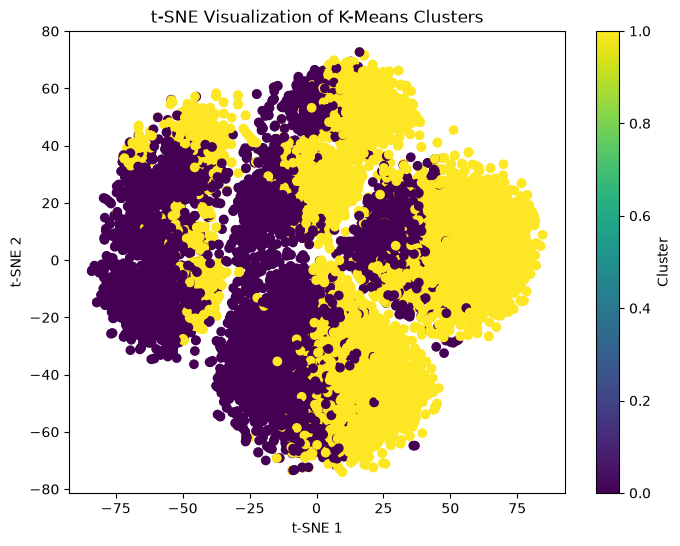

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
scatter=plt.scatter(pred[:,0],pred[:,1],c=df['cluster'])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of K-Means Clusters")
plt.colorbar(scatter, label="Cluster")
plt.show()

### t-SNE Visualization Interpretation

The t-SNE visualization reveals local structure in the dataset and shows how the K-Means clusters are distributed in two dimensions.

The two clusters show noticeable separation in several regions, although some overlap between them is still present.

Unlike PCA, the t-SNE axes do not have a direct meaning. The important information is the relative position of the points and which observations appear close to each other.

## Step 2- Compare PCA and t-SNE

### PCA vs. t-SNE Visualization

### Comparison and Interpretation

The PCA visualization showed the overall structure of the dataset, but there was considerable overlap between the groups.

The first two PCA components preserved approximately **25.24% of the total variance**.

The t-SNE visualization revealed clearer local patterns and groupings in the data because t-SNE focuses on preserving local neighborhoods.

PCA is useful for dimensionality reduction, compression, and visualization, while t-SNE is mainly used for visualization and exploring local structure.

The axes in the t-SNE plot do not have a direct meaning. The important information is the relative position of the points and which observations appear close to each other.

## Step 3- Anomaly Detection with Isolation Forest



### Apply Isolation Forest to the Dataset

In [9]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.05,random_state=42)
labels=iso.fit_predict(X_scaled)
labels

array([1, 1, 1, ..., 1, 1, 1], shape=(9000,))

### Count Normal and Anomalous Points

In [10]:
pd.Series(labels).value_counts()

 1    8550
-1     450
Name: count, dtype: int64

### Isolation Forest Results

Isolation Forest identified:

- **8,550 normal points**
- **450 anomalous points**

The model used `contamination=0.05`, meaning approximately 5% of the dataset was expected to be anomalous.

The flagged points are observations that Isolation Forest considers unusual compared with the overall structure of the dataset. They are not necessarily errors or incorrect records.

## Step 4- Inspect Two Flagged Anomalies

### Add the Anomaly Labels to the Dataset

In [11]:
df["anomaly"] = labels

### Extract the Anomalous Points

In [12]:
anomalies = df[df["anomaly"] == -1]

### Inspect Two Flagged Anomalies

In [13]:
anomalies.head(2)

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,resting_heart_rate,max_heart_rate_achieved,chest_pain_type,exercise_induced_angina,st_depression,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,cluster,anomaly
17,61,Female,138,95,272,44,191,141,155,7.2,31.3,74,121,Asymptomatic,1,0.1,0,Never,0.4,103,7.7,25.8,0,4593,46.7,1,0,-1
19,36,Female,102,62,170,86,66,86,64,4.4,15.9,63,209,Asymptomatic,0,1.1,0,Never,1.7,266,5.3,32.2,0,7563,73.1,0,1,-1


In [14]:
df.describe()

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,resting_heart_rate,max_heart_rate_achieved,exercise_induced_angina,st_depression,family_history,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,cluster,anomaly
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,25.264922,80.912667,164.838333,0.229111,1.012911,0.272444,5.708733,139.493444,6.994578,47.968033,0.442778,6163.659333,59.467400,0.303000,0.514556,0.900000
std,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,4.371525,8.604685,21.290773,0.420284,0.957090,0.445242,5.070642,63.660433,1.104215,16.162484,0.496742,2170.685995,14.476064,0.459581,0.499816,0.435914
min,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,15.000000,48.000000,93.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.100000,0.000000,0.000000,500.000000,4.800000,0.000000,0.000000,-1.000000
25%,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,22.300000,75.000000,150.000000,0.000000,0.400000,0.000000,2.200000,96.000000,6.300000,37.100000,0.000000,4658.000000,49.700000,0.000000,0.000000,1.000000
50%,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,25.300000,81.000000,166.000000,0.000000,0.700000,0.000000,4.200000,139.000000,7.000000,48.100000,0.000000,6178.000000,59.600000,0.000000,1.000000,1.000000
75%,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,28.200000,87.000000,180.000000,0.000000,1.400000,1.000000,7.700000,183.000000,7.700000,58.900000,1.000000,7632.750000,69.100000,1.000000,1.000000,1.000000
max,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,43.300000,111.000000,210.000000,1.000000,6.500000,1.000000,45.900000,366.000000,11.000000,100.000000,1.000000,13950.000000,100.000000,1.000000,1.000000,1.000000


### Analysis of Two Flagged Anomalies

#### Anomaly 1 — Patient 17

Patient 17 contains several values that are unusual compared with the overall dataset.

For example:

- LDL is **191**, compared with a dataset mean of approximately **103.28**.
- Total cholesterol is **272**, compared with a mean of approximately **188.75**.
- Fasting blood sugar is **155**, compared with a mean of approximately **119.47**.
- HbA1c is **7.2**, compared with a mean of approximately **5.79**.
- BMI is **31.3**, compared with a mean of approximately **25.26**.

The combination of several relatively high values may make this patient different from the majority of observations, which could explain why Isolation Forest flagged this point as an anomaly.

#### Anomaly 2 — Patient 19

Patient 19 shows a different pattern of unusual values.

For example:

- BMI is **15.9**, compared with a dataset mean of approximately **25.26**.
- Maximum heart rate achieved is **209**, compared with a mean of approximately **164.84** and a maximum of **210**.
- HDL is **86**, compared with a mean of approximately **55.22**.
- Fasting blood sugar is **64**, compared with a mean of approximately **119.47**.
- HbA1c is **4.4**, compared with a mean of approximately **5.79**.

The combination of very low and very high feature values makes this observation unusual compared with the general pattern of the dataset, which may explain why Isolation Forest flagged it as an anomaly.

### Interpretation

Isolation Forest does not necessarily flag a point because of one individual feature. It considers the overall combination of features.

Therefore, these explanations are hypotheses based on comparing the flagged observations with the overall dataset statistics. Being classified as an anomaly does not necessarily mean that the observation is incorrect or medically abnormal; it means that its feature pattern is unusual compared with most observations in this dataset.